# 🤖 Notebook 03: Entrenamiento de Modelos

**Proyecto:** Sistema de Detección de Phishing con Machine Learning  
**Autor:** [Tu Nombre]  
**Universidad:** [Tu Universidad]  
**Fecha:** 2024-2025

---

## Objetivos

1. ✅ Entrenar **8 modelos de clasificación**
2. ✅ Aplicar **Hyperparameter Tuning** (GridSearchCV/RandomizedSearchCV)
3. ✅ **Cross-validation** (5-fold)
4. ✅ Evaluar modelos en validation set
5. ✅ Guardar modelos entrenados
6. ✅ Comparar rendimiento

---

## Modelos a Entrenar

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. Gradient Boosting
6. SVM (Support Vector Machine)
7. KNN (K-Nearest Neighbors)
8. Naive Bayes

---

## 1. Importar Librerías

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Módulos propios
from model_training import ModelTrainingManager
from evaluation import ModelEvaluator, ModelComparator, VisualizationGenerator

# Configuración
pd.set_option('display.max_columns', None)
%matplotlib inline

# Semilla
RANDOM_STATE = 42

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Cargar Datos Preprocesados

In [2]:
# Cargar datos preprocesados
print("Cargando datos preprocesados...")

X_train = joblib.load('../data/processed/X_train.pkl')
X_val = joblib.load('../data/processed/X_val.pkl')
X_test = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_val = joblib.load('../data/processed/y_val.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')

print("\n✓ Datos cargados exitosamente")
print(f"\nShapes:")
print(f"  - Train: {X_train.shape}")
print(f"  - Validation: {X_val.shape}")
print(f"  - Test: {X_test.shape}")

print(f"\nDistribución Train:")
print(y_train.value_counts())
print(f"\nDistribución Validation:")
print(y_val.value_counts())

Cargando datos preprocesados...



✓ Datos cargados exitosamente

Shapes:
  - Train: (188790, 40)
  - Validation: (35248, 40)
  - Test: (35249, 40)

Distribución Train:
__label__
0    94395
1    94395
Name: count, dtype: int64

Distribución Validation:
__label__
1    20227
0    15021
Name: count, dtype: int64


## 3. Configuración de Entrenamiento

In [3]:
# Configuración
USE_GRID_SEARCH = True  # Usar hyperparameter tuning (más lento pero mejor)
CV_FOLDS = 5  # Cross-validation folds

print(f"Configuración de entrenamiento:")
print(f"  - Grid Search: {'Sí' if USE_GRID_SEARCH else 'No'}")
print(f"  - CV Folds: {CV_FOLDS}")
print(f"  - Random State: {RANDOM_STATE}")

if USE_GRID_SEARCH:
    print("\n⚠ Modo Grid Search activado - El entrenamiento tomará más tiempo")
    print("   pero producirá mejores resultados.")

Configuración de entrenamiento:
  - Grid Search: Sí
  - CV Folds: 5
  - Random State: 42

⚠ Modo Grid Search activado - El entrenamiento tomará más tiempo
   pero producirá mejores resultados.


## 4. Entrenamiento de Todos los Modelos

Entrenaremos los 8 modelos con hyperparameter tuning.

In [4]:
# Inicializar manager
manager = ModelTrainingManager(random_state=RANDOM_STATE)

# SOLO ENTRENAR 4 MODELOS PRINCIPALES (más rápido)
models_to_train = ['logistic_regression', 'random_forest', 'xgboost', 'svm']

print("="*70)
print("    ENTRENAMIENTO DE 4 MODELOS PRINCIPALES")
print("="*70)
print(f"\nModelos seleccionados: {len(models_to_train)}")
for model in models_to_train:
    print(f"  - {model.replace('_', ' ').title()}")
print(f"\nEsto tomará aproximadamente 3-5 minutos con GPU...\n")

# Entrenar solo los 4 modelos principales
trainers = manager.train_all_models(
    X_train,
    y_train,
    use_grid_search=USE_GRID_SEARCH,
    models_to_train=models_to_train
)

print("\n" + "="*70)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*70)
print(f"\nModelos entrenados: {len(trainers)}")

2025-11-19 23:12:44,108 - model_training - INFO - Logistic Regression Trainer inicializado


2025-11-19 23:12:44,108 - model_training - INFO - Decision Tree Trainer inicializado


2025-11-19 23:12:44,108 - model_training - INFO - Random Forest Trainer inicializado


2025-11-19 23:12:44,108 - model_training - INFO - XGBoost Trainer inicializado


2025-11-19 23:12:44,108 - model_training - INFO - Gradient Boosting Trainer inicializado


...

2025-11-19 23:15:12,412 - model_training - INFO - Mejores parámetros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


2025-11-19 23:15:12,412 - model_training - INFO - Tiempo de entrenamiento: 64.84s


2025-11-19 23:15:12,412 - model_training - INFO - ✓ svm entrenado exitosamente


2025-11-19 23:15:12,412 - model_training - INFO - 
=== Entrenamiento de modelos completado ===



✅ ENTRENAMIENTO COMPLETADO

Modelos entrenados: 4


## 5. Evaluación en Validation Set

In [5]:
# Crear comparador
comparator = ModelComparator()

# Comparar modelos en validation set
print("Evaluando modelos en Validation Set...\n")

results_val = comparator.compare_models(
    trainers,
    X_val,
    y_val,
    include_time=True
)

print("\n" + "="*70)
print("RESULTADOS EN VALIDATION SET")
print("="*70)
print(results_val.to_string(index=False))

2025-11-19 23:15:12,427 - evaluation - INFO - ModelEvaluator inicializado


2025-11-19 23:15:12,427 - evaluation - INFO - ModelComparator inicializado


2025-11-19 23:15:12,427 - evaluation - INFO - Comparando 4 modelos...


2025-11-19 23:15:12,427 - evaluation - INFO - Evaluando modelo: logistic_regression


2025-11-19 23:15:12,475 - evaluation - INFO -   Accuracy: 1.0000


...

2025-11-19 23:15:12,853 - evaluation - INFO -   F1-Score: 1.0000


2025-11-19 23:15:12,853 - evaluation - INFO -   ROC-AUC: 1.0000


2025-11-19 23:15:12,853 - evaluation - INFO - 
=== Resultados de Comparación ===


2025-11-19 23:15:12,868 - evaluation - INFO - 
 accuracy  precision  recall  f1_score  roc_auc          model_name  training_time
 1.000000   1.000000     1.0  1.000000      1.0       random_forest      54.968172
 1.000000   1.000000     1.0  1.000000      1.0             xgboost       5.986358
 0.999972   0.999951     1.0  0.999975      1.0 logistic_regression      22.483632
 0.999972   0.999951     1.0  0.999975      1.0                 svm      64.836454



RESULTADOS EN VALIDATION SET
 accuracy  precision  recall  f1_score  roc_auc          model_name  training_time
 1.000000   1.000000     1.0  1.000000      1.0       random_forest      54.968172
 1.000000   1.000000     1.0  1.000000      1.0             xgboost       5.986358
 0.999972   0.999951     1.0  0.999975      1.0 logistic_regression      22.483632
 0.999972   0.999951     1.0  0.999975      1.0                 svm      64.836454


### 5.1 Visualización de Resultados

✓ Visualización guardada: ../results/visualizations/models_comparison_val.png


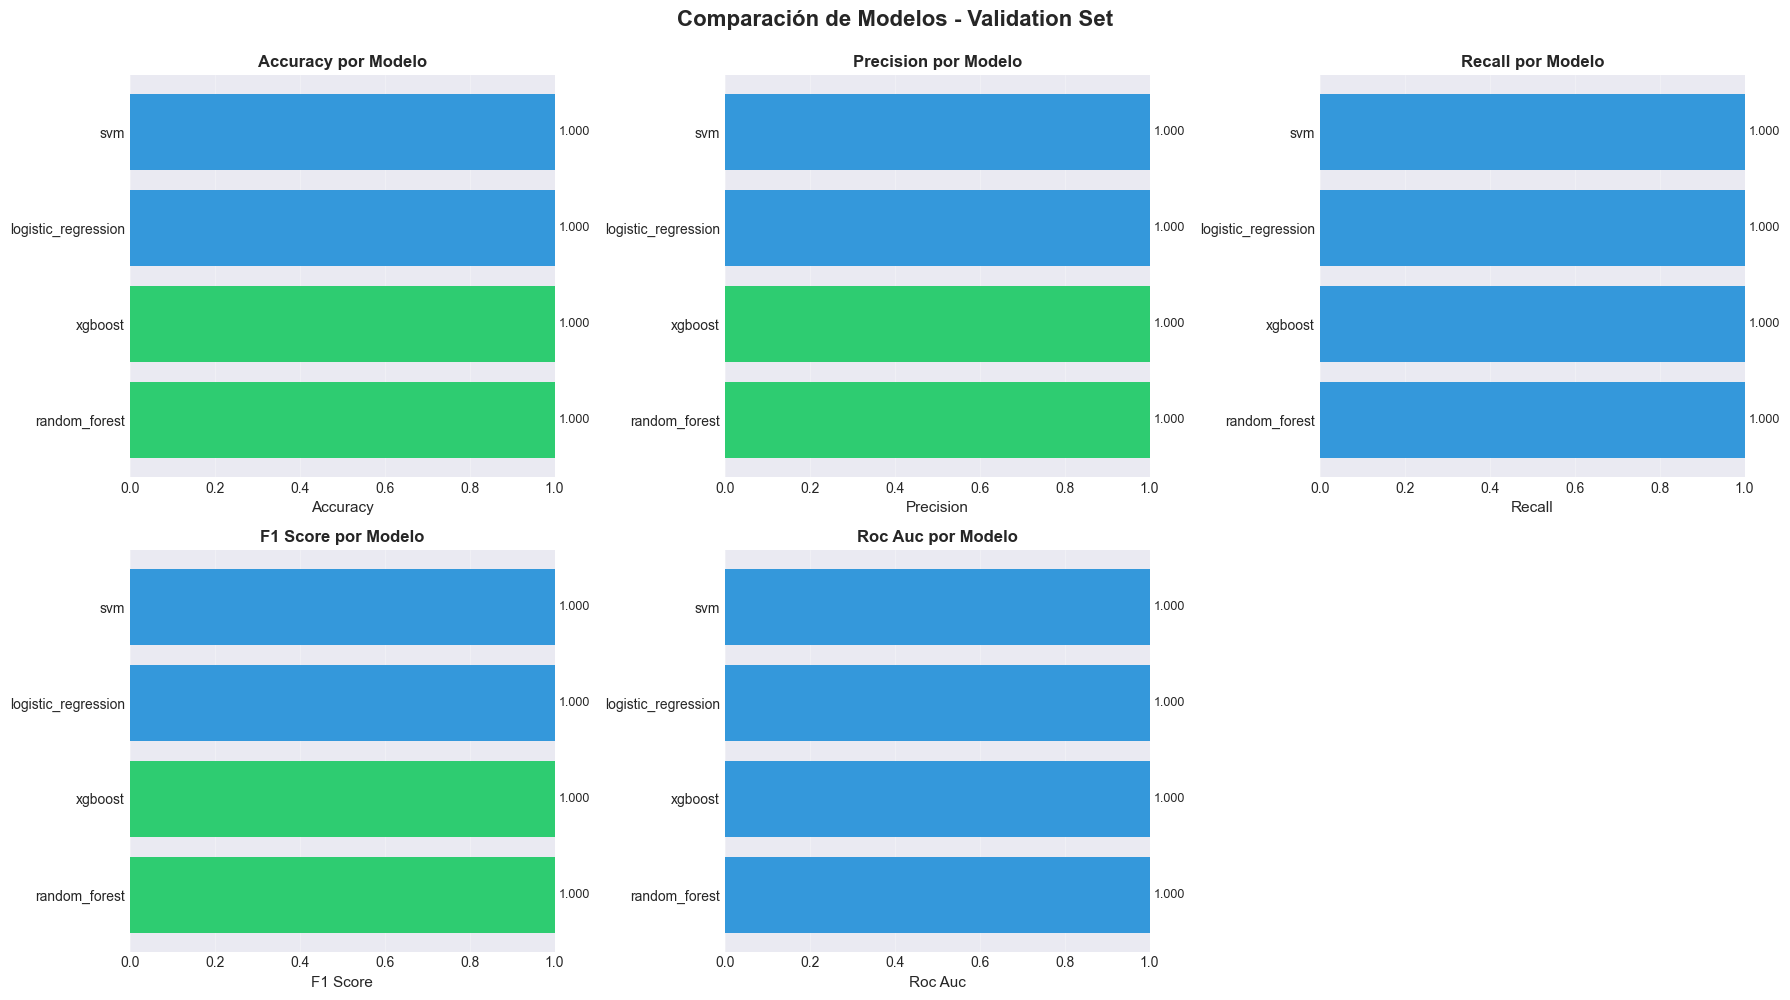

In [6]:
# Gráfico de barras comparativo
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    df_sorted = results_val.sort_values(metric, ascending=False)
    
    colors = ['#2ecc71' if val > df_sorted[metric].median() else '#3498db' 
              for val in df_sorted[metric]]
    
    ax.barh(df_sorted['model_name'], df_sorted[metric], color=colors)
    ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{metric.replace("_", " ").title()} por Modelo', 
                 fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Valores
    for i, v in enumerate(df_sorted[metric]):
        if pd.notna(v):
            ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Ocultar último eje
fig.delaxes(axes[5])

plt.suptitle('Comparación de Modelos - Validation Set', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Guardar
output_path = '../results/visualizations/models_comparison_val.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Visualización guardada: {output_path}")
plt.show()

## 6. Matrices de Confusión

In [7]:
# Generar matrices de confusión para todos los modelos
viz_generator = VisualizationGenerator(
    output_dir='../results/visualizations',
    dpi=300
)

print("Generando matrices de confusión...\n")

for name, trainer in trainers.items():
    # Predicciones
    y_pred = trainer.predict(X_val)
    
    # Generar matriz
    viz_generator.plot_confusion_matrix(
        y_val,
        y_pred,
        model_name=name,
        save=True
    )
    print(f"  ✓ {name}")

print("\n✓ Matrices de confusión generadas")

2025-11-19 23:15:13,991 - evaluation - INFO - VisualizationGenerator inicializado. Output: ../results/visualizations, DPI: 300


2025-11-19 23:15:13,998 - evaluation - INFO - Generando matriz de confusión para logistic_regression...


Generando matrices de confusión...



2025-11-19 23:15:14,272 - evaluation - INFO - Matriz de confusión guardada: ../results/visualizations\confusion_matrix_logistic_regression.png


2025-11-19 23:15:14,340 - evaluation - INFO - Generando matriz de confusión para random_forest...


...

2025-11-19 23:15:14,835 - evaluation - INFO - Matriz de confusión guardada: ../results/visualizations\confusion_matrix_xgboost.png


2025-11-19 23:15:14,889 - evaluation - INFO - Generando matriz de confusión para svm...


  ✓ xgboost


2025-11-19 23:15:15,131 - evaluation - INFO - Matriz de confusión guardada: ../results/visualizations\confusion_matrix_svm.png


  ✓ svm

✓ Matrices de confusión generadas


## 7. Curvas ROC Comparativas

In [8]:
# Preparar datos para curvas ROC
models_roc_data = {}

for name, trainer in trainers.items():
    if hasattr(trainer.model, 'predict_proba'):
        y_proba = trainer.predict_proba(X_val)
        models_roc_data[name] = (y_val, y_proba)

# Generar curvas ROC comparativas
print(f"Generando curvas ROC de {len(models_roc_data)} modelos...\n")

viz_generator.plot_multiple_roc_curves(
    models_roc_data,
    save=True
)

print("✓ Curvas ROC generadas")

Generando curvas ROC de 4 modelos...


2025-11-19 23:15:15,319 - evaluation - INFO - Generando curvas ROC comparativas de 4 modelos...


2025-11-19 23:15:15,724 - evaluation - INFO - Curvas ROC comparativas guardadas: ../results/visualizations\roc_curves_comparison.png


✓ Curvas ROC generadas


## 8. Mejor Modelo

In [9]:
# Identificar mejor modelo por F1-Score
best_idx = results_val['f1_score'].idxmax()
best_model_name = results_val.loc[best_idx, 'model_name']
best_f1 = results_val.loc[best_idx, 'f1_score']

print("="*70)
print("🏆 MEJOR MODELO (por F1-Score)")
print("="*70)
print(f"\nModelo: {best_model_name}")
print(f"\nMétricas en Validation Set:")
print(f"  - Accuracy:  {results_val.loc[best_idx, 'accuracy']:.4f}")
print(f"  - Precision: {results_val.loc[best_idx, 'precision']:.4f}")
print(f"  - Recall:    {results_val.loc[best_idx, 'recall']:.4f}")
print(f"  - F1-Score:  {results_val.loc[best_idx, 'f1_score']:.4f}")
print(f"  - ROC-AUC:   {results_val.loc[best_idx, 'roc_auc']:.4f}")

if 'training_time' in results_val.columns:
    print(f"\nTiempo de entrenamiento: {results_val.loc[best_idx, 'training_time']:.2f}s")

print("\n" + "="*70)

🏆 MEJOR MODELO (por F1-Score)

Modelo: random_forest

Métricas en Validation Set:
  - Accuracy:  1.0000
  - Precision: 1.0000
  - Recall:    1.0000
  - F1-Score:  1.0000
  - ROC-AUC:   1.0000

Tiempo de entrenamiento: 54.97s



## 9. Evaluación en Test Set (Solo Mejor Modelo)

Evaluamos el mejor modelo en el test set para verificar generalización.

In [10]:
# Obtener mejor trainer
best_trainer = trainers[best_model_name]

# Evaluar en test set
evaluator = ModelEvaluator()
test_metrics = evaluator.evaluate_model(
    best_trainer.model,
    X_test,
    y_test,
    model_name=best_model_name
)

print("\n" + "="*70)
print(f"EVALUACIÓN EN TEST SET - {best_model_name}")
print("="*70)
print(f"\n  - Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  - Precision: {test_metrics['precision']:.4f}")
print(f"  - Recall:    {test_metrics['recall']:.4f}")
print(f"  - F1-Score:  {test_metrics['f1_score']:.4f}")
print(f"  - ROC-AUC:   {test_metrics['roc_auc']:.4f}")
print("\n" + "="*70)

# Comparar con validation
print("\nDiferencia Val vs Test:")
print(f"  Accuracy:  {results_val.loc[best_idx, 'accuracy'] - test_metrics['accuracy']:+.4f}")
print(f"  F1-Score:  {results_val.loc[best_idx, 'f1_score'] - test_metrics['f1_score']:+.4f}")
print(f"  ROC-AUC:   {results_val.loc[best_idx, 'roc_auc'] - test_metrics['roc_auc']:+.4f}")

2025-11-19 23:15:15,743 - evaluation - INFO - ModelEvaluator inicializado


2025-11-19 23:15:15,743 - evaluation - INFO - Evaluando modelo: random_forest


2025-11-19 23:15:15,875 - evaluation - INFO -   Accuracy: 1.0000


2025-11-19 23:15:15,875 - evaluation - INFO -   Precision: 1.0000


2025-11-19 23:15:15,875 - evaluation - INFO -   Recall: 1.0000


2025-11-19 23:15:15,875 - evaluation - INFO -   F1-Score: 1.0000


2025-11-19 23:15:15,875 - evaluation - INFO -   ROC-AUC: 1.0000



EVALUACIÓN EN TEST SET - random_forest

  - Accuracy:  1.0000
  - Precision: 1.0000
  - Recall:    1.0000
  - F1-Score:  1.0000
  - ROC-AUC:   1.0000


Diferencia Val vs Test:
  Accuracy:  +0.0000
  F1-Score:  +0.0000
  ROC-AUC:   +0.0000


## 10. Guardar Modelos Entrenados

In [11]:
# Guardar todos los modelos
print("Guardando modelos entrenados...\n")

manager.save_all_models(trainers, output_dir='../models')

print("\n✓ Todos los modelos guardados en ../models/")

2025-11-19 23:15:15,892 - model_training - INFO - Guardando modelos en: ../models


2025-11-19 23:15:15,892 - model_training - INFO - Modelo Logistic Regression guardado en: ../models\logistic_regression.pkl


2025-11-19 23:15:15,914 - model_training - INFO - Modelo Random Forest guardado en: ../models\random_forest.pkl


Guardando modelos entrenados...



2025-11-19 23:15:15,926 - model_training - INFO - Modelo XGBoost guardado en: ../models\xgboost.pkl


2025-11-19 23:15:15,926 - model_training - INFO - Modelo SVM guardado en: ../models\svm.pkl


2025-11-19 23:15:15,926 - model_training - INFO - Todos los modelos guardados exitosamente



✓ Todos los modelos guardados en ../models/


## 11. Guardar Resultados

In [12]:
# Guardar tabla de comparación
results_path = '../results/metrics/model_comparison.csv'
comparator.save_comparison_table(results_val, results_path)

print(f"✓ Resultados guardados: {results_path}")

# Guardar nombre del mejor modelo
with open('../results/metrics/best_model.txt', 'w') as f:
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"F1-Score (Val): {best_f1:.4f}\n")
    f.write(f"F1-Score (Test): {test_metrics['f1_score']:.4f}\n")

print("✓ Información del mejor modelo guardada")

2025-11-19 23:15:15,975 - evaluation - INFO - Tabla de comparación guardada: ../results/metrics/model_comparison.csv


✓ Resultados guardados: ../results/metrics/model_comparison.csv
✓ Información del mejor modelo guardada


## 12. Resumen Final

In [13]:
print("="*70)
print("                 RESUMEN DEL ENTRENAMIENTO")
print("="*70)

print(f"\n🤖 MODELOS ENTRENADOS: {len(trainers)}")
for name in trainers.keys():
    print(f"  ✓ {name}")

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"  - F1-Score (Validation): {best_f1:.4f}")
print(f"  - F1-Score (Test): {test_metrics['f1_score']:.4f}")

print(f"\n📊 TOP 3 MODELOS (por F1-Score):")
top3 = results_val.nlargest(3, 'f1_score')[['model_name', 'f1_score', 'accuracy']]
for idx, row in top3.iterrows():
    print(f"  {idx+1}. {row['model_name']}: F1={row['f1_score']:.4f}, Acc={row['accuracy']:.4f}")

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"  - Modelos: ../models/*.pkl ({len(trainers)} archivos)")
print(f"  - Resultados: {results_path}")
print(f"  - Visualizaciones: ../results/visualizations/")

print("\n" + "="*70)
print("\n✅ ENTRENAMIENTO DE MODELOS COMPLETADO")
print("\n📌 Próximo paso: Notebook 04 - Ensemble Methods")
print("="*70)

                 RESUMEN DEL ENTRENAMIENTO

🤖 MODELOS ENTRENADOS: 4
  ✓ logistic_regression
  ✓ random_forest
  ✓ xgboost
  ✓ svm

🏆 MEJOR MODELO: random_forest
  - F1-Score (Validation): 1.0000
  - F1-Score (Test): 1.0000

📊 TOP 3 MODELOS (por F1-Score):
  2. random_forest: F1=1.0000, Acc=1.0000
  3. xgboost: F1=1.0000, Acc=1.0000
  1. logistic_regression: F1=1.0000, Acc=1.0000

💾 ARCHIVOS GENERADOS:
  - Modelos: ../models/*.pkl (4 archivos)
  - Resultados: ../results/metrics/model_comparison.csv
  - Visualizaciones: ../results/visualizations/


✅ ENTRENAMIENTO DE MODELOS COMPLETADO

📌 Próximo paso: Notebook 04 - Ensemble Methods
